In [2]:
import scvi
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
sc.set_figure_params(figsize=(8, 8))

Global seed set to 0


In [3]:
adata = sc.read_h5ad('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/extended/processed/anndata.h5ad')

In [3]:
# preprocessing
sc.pp.filter_genes(adata, min_counts=3)
adata.layers["counts"] = adata.X.copy() # preserve counts
adata.raw = adata # freeze the state in `.raw`

sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2500,
    subset=True,
    layer="counts",
    flavor="cell_ranger",
    batch_key="stage"
)

/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:475: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hvg = hvg.append(missing_hvg, ignore_index=True)
/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:475: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hvg = hvg.append(missing_hvg, ignore_index=True)
/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:475: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hvg = hvg.append(missing_hvg, ignore_index=True)
/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/scanpy/preprocessing/_highly

In [101]:
genes = adata.var
genes.to_csv('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/extended/results/genes_scanvi.csv')

# Train model

In [32]:
scvi.model.SCVI.setup_anndata(
    adata,
    layer="counts",
    batch_key="stage",
    categorical_covariate_keys=["sample"]
)

INFO     Using batches from adata.obs["stage"]                                               
INFO     No label_key inputted, assuming all cells have same label                           
INFO     Using data from adata.layers["counts"]                                              
INFO     Successfully registered anndata object containing 115559 cells, 2500 vars, 13       
         batches, 1 labels, and 0 proteins. Also registered 1 extra categorical covariates   
         and 0 extra continuous covariates.                                                  
INFO     Please do not further modify adata until model is trained.                          


/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/scvi/data/_anndata.py:315: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  warnings.warn(


In [5]:
model = scvi.model.SCVI(adata, n_latent=40)

In [ ]:
model.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
Set SLURM handle signals.


Epoch 31/69:  43%|████▎     | 30/69 [1:11:32<1:32:45, 142.72s/it, loss=1.32e+03, v_num=1]

In [ ]:
model.save("/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/extended/processed/scvi_model/")

# Load the model

In [5]:
model = scvi.model.SCVI.load("/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/extended/processed/scvi_model/", adata)

INFO     Using data from adata.layers["counts"]                                              


/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function transfer_anndata_setup is deprecated; This method will be removed in 0.15.0. Please avoid building any new dependencies on it.
  warnings.warn(msg, category=FutureWarning)


INFO     Registered keys:['X', 'batch_indices', 'labels', 'cat_covs']                        
INFO     Successfully registered anndata object containing 115559 cells, 2500 vars, 13       
         batches, 1 labels, and 0 proteins. Also registered 1 extra categorical covariates   
         and 0 extra continuous covariates.                                                  


/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/scvi/data/_anndata.py:315: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  warnings.warn(


In [6]:
latent = model.get_latent_representation()
adata.obsm["X_scVI"] = latent
adata.layers["scvi_normalized"] = model.get_normalized_expression(
    library_size=10e4
)

In [7]:
adata.obs.tail()

,sample,stage,celltype_original,celltype,idx,umapX,umapY,_scvi_batch,_scvi_labels
ext_cell_314786,98,E9.5,Paraxial mesoderm,Cranial mesoderm,115555,21.290897,10.205814,11,0
ext_cell_329516,101,E9.5,Allantois,Mesenchyme,115556,14.249460,-1.476499,11,0
ext_cell_341126,103,E9.5,Paraxial mesoderm,Sclerotome,115557,20.044716,9.224581,11,0
ext_cell_334312,102,E9.5,Paraxial mesoderm,Cranial mesoderm,115558,20.457296,10.826429,11,0
ext_cell_311352,98,E9.5,Spinal cord,Optic vesicle,115559,9.451382,21.117533,11,0


In [8]:
# use scVI latent space for UMAP generation
sc.pp.neighbors(adata, use_rep="X_scVI", n_neighbors=35)
sc.tl.umap(adata, min_dist=0.4)

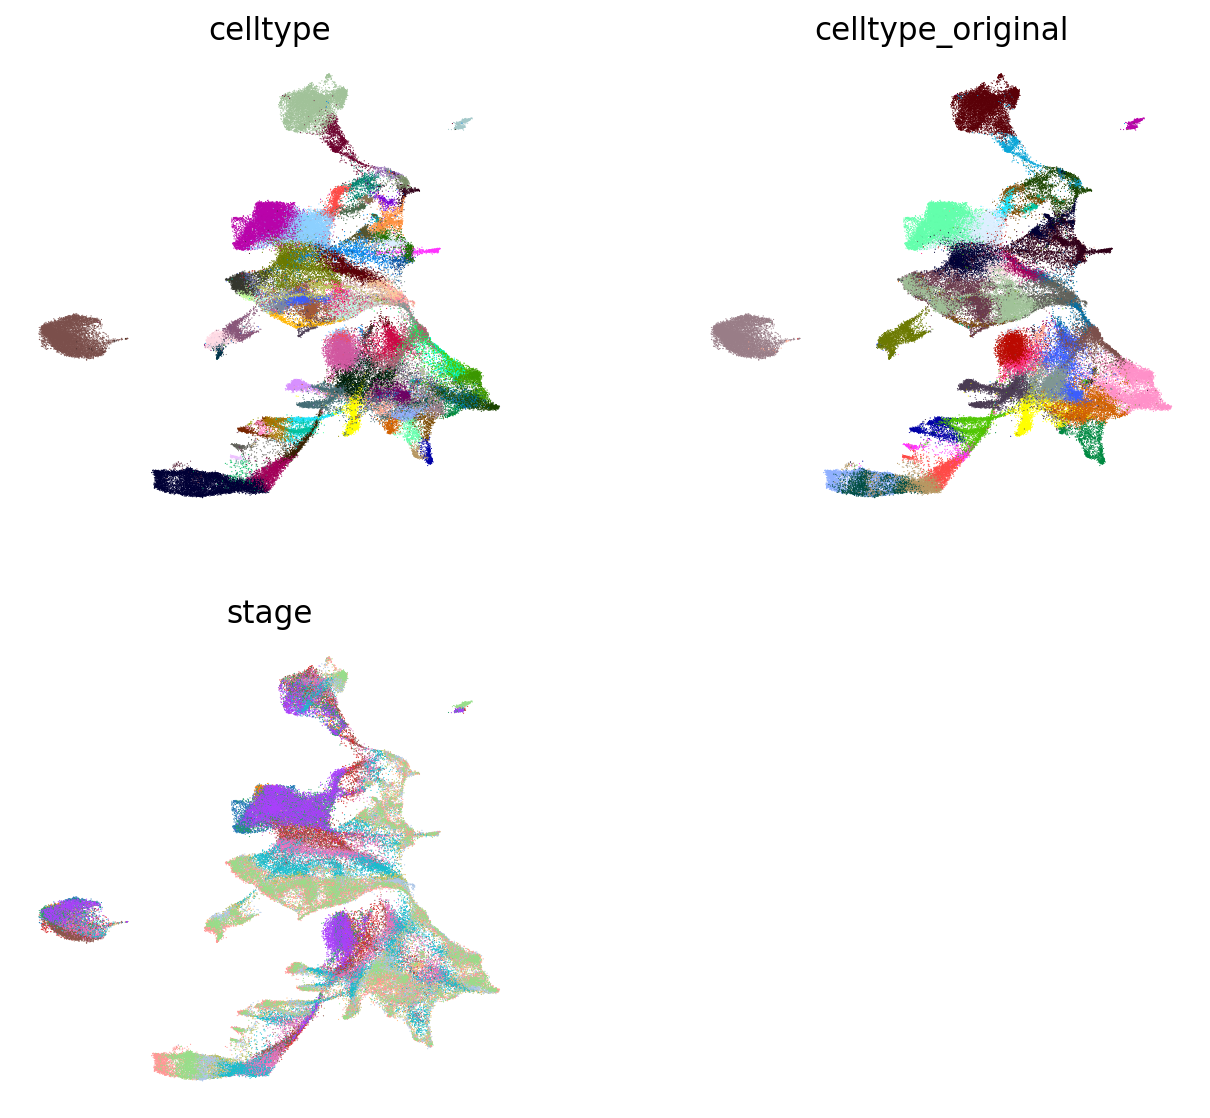

In [9]:
sc.pl.umap(
    adata,
    color=["celltype", "celltype_original", "stage"],
    frameon=False,
    ncols=2, legend_loc='none'
)

In [11]:
umap = pd.DataFrame(adata.obsm['X_umap'])
latent = pd.DataFrame(adata.obsm['X_scVI'])

umap.to_csv('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/extended/results/dim_reduction/umap.csv')
latent.to_csv('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/extended/results/dim_reduction/latent.csv')

## Ref mapping test

In [11]:
adata_query = sc.read_h5ad("/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/processed/anndata_scanvi.h5ad")

In [12]:
adata_query.layers["counts"] = adata_query.X.copy() # preserve counts
adata_query.raw = adata_query # freeze the state in `.raw`

In [13]:
vae_q = scvi.model.SCVI.load_query_data(
    adata_query,
    model
)

INFO     .obs[_scvi_labels] not found in target, assuming every cell is same category        
INFO     Using data from adata.layers["counts"]                                              


/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/scvi/model/base/_archesmixin.py:95: UserWarning: Query integration should be performed using models trained with version >= 0.8
  warnings.warn(
/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function transfer_anndata_setup is deprecated; This method will be removed in 0.15.0. Please avoid building any new dependencies on it.
  warnings.warn(msg, category=FutureWarning)


INFO     Registered keys:['X', 'batch_indices', 'labels', 'cat_covs']                        
INFO     Successfully registered anndata object containing 45670 cells, 2500 vars, 13        
         batches, 1 labels, and 0 proteins. Also registered 1 extra categorical covariates   
         and 0 extra continuous covariates.                                                  


/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/scvi/data/_anndata.py:465: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if c not in mapping:
/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/scvi/data/_anndata.py:315: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  warnings.warn(


In [14]:
vae_q.train(plan_kwargs=dict(weight_decay=0.0))
adata_query.obsm["X_scVI"] = vae_q.get_latent_representation()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
Set SLURM handle signals.


Epoch 175/175: 100%|██████████| 175/175 [1:31:49<00:00, 31.48s/it, loss=2.04e+03, v_num=1]


In [15]:
sc.pp.neighbors(adata_query, use_rep="X_scVI")
sc.tl.leiden(adata_query)
sc.tl.umap(adata_query)

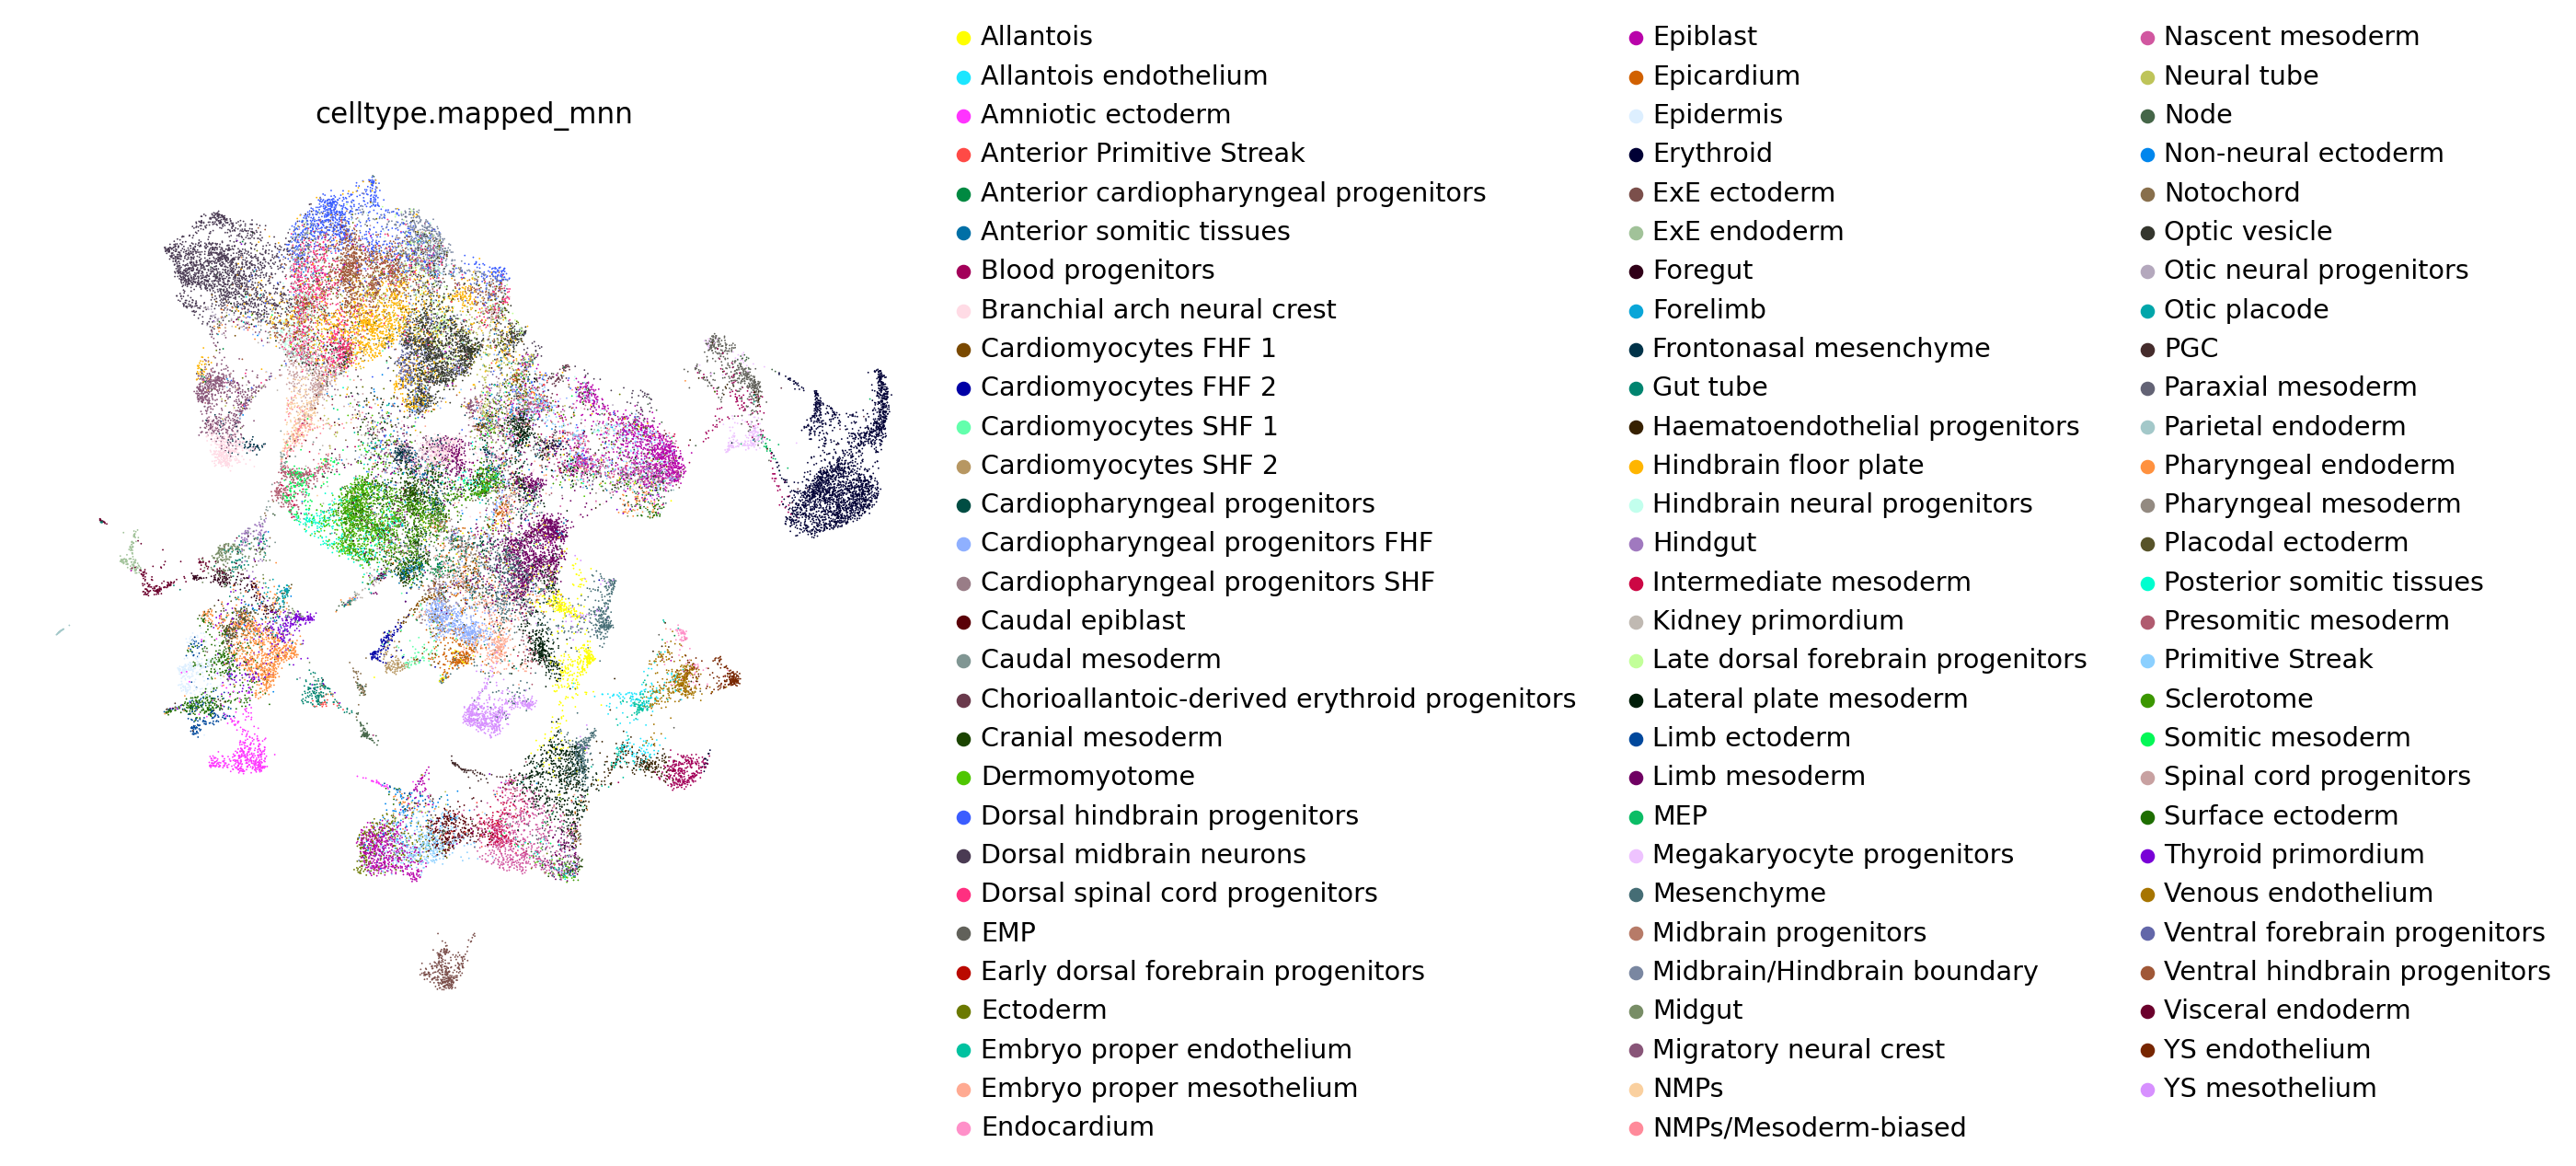

In [22]:
sc.pl.umap(
    adata_query,
    color=["celltype.mapped_mnn"],
    frameon=False,
    ncols=1 #, legend_loc='none'
)

In [24]:
umap = pd.DataFrame(adata_query.obsm['X_umap'])
latent = pd.DataFrame(adata_query.obsm['X_scVI'])

umap.to_csv('/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/results/rna/scvi/umap_ext.csv')
latent.to_csv('/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/results/rna/scvi/latent_ext.csv')

In [ ]:
adata_full = adata_query.concatenate(adata)

In [37]:
adata_full.obsm["X_scVI"] = vae_q.get_latent_representation(adata_full)

In [40]:
# use scVI latent space for UMAP generation
sc.pp.neighbors(adata_full, use_rep="X_scVI", n_neighbors=35)
sc.tl.umap(adata_full, min_dist=0.4)

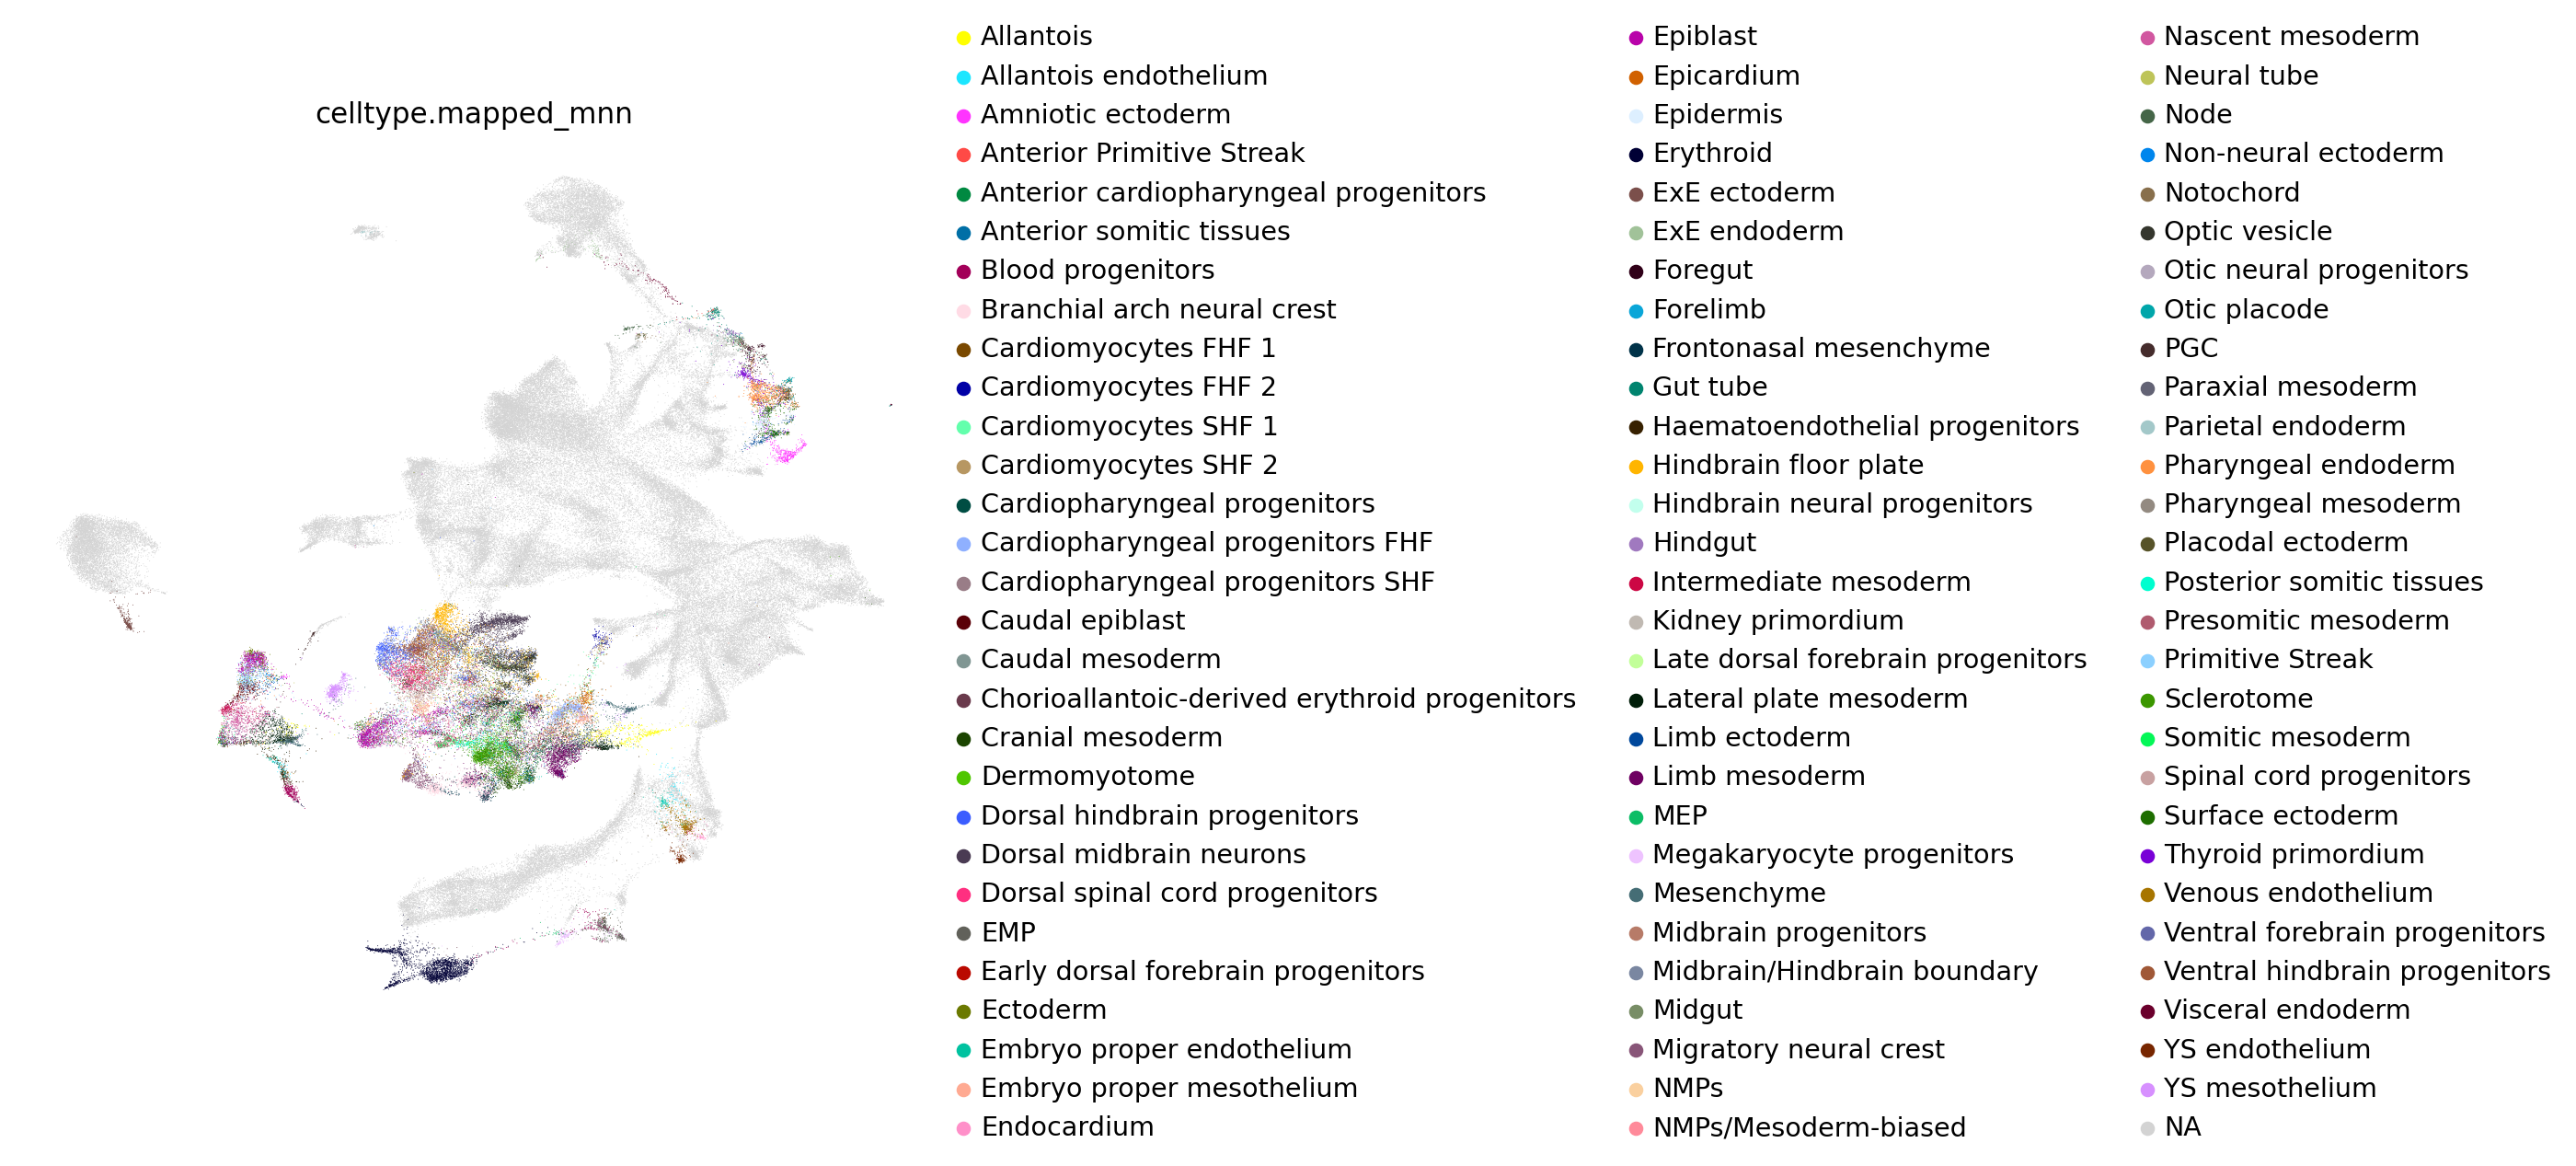

In [41]:
sc.pl.umap(
    adata_full,
    color=["celltype.mapped_mnn"],
    frameon=False,
    ncols=1 #, legend_loc='none'
)

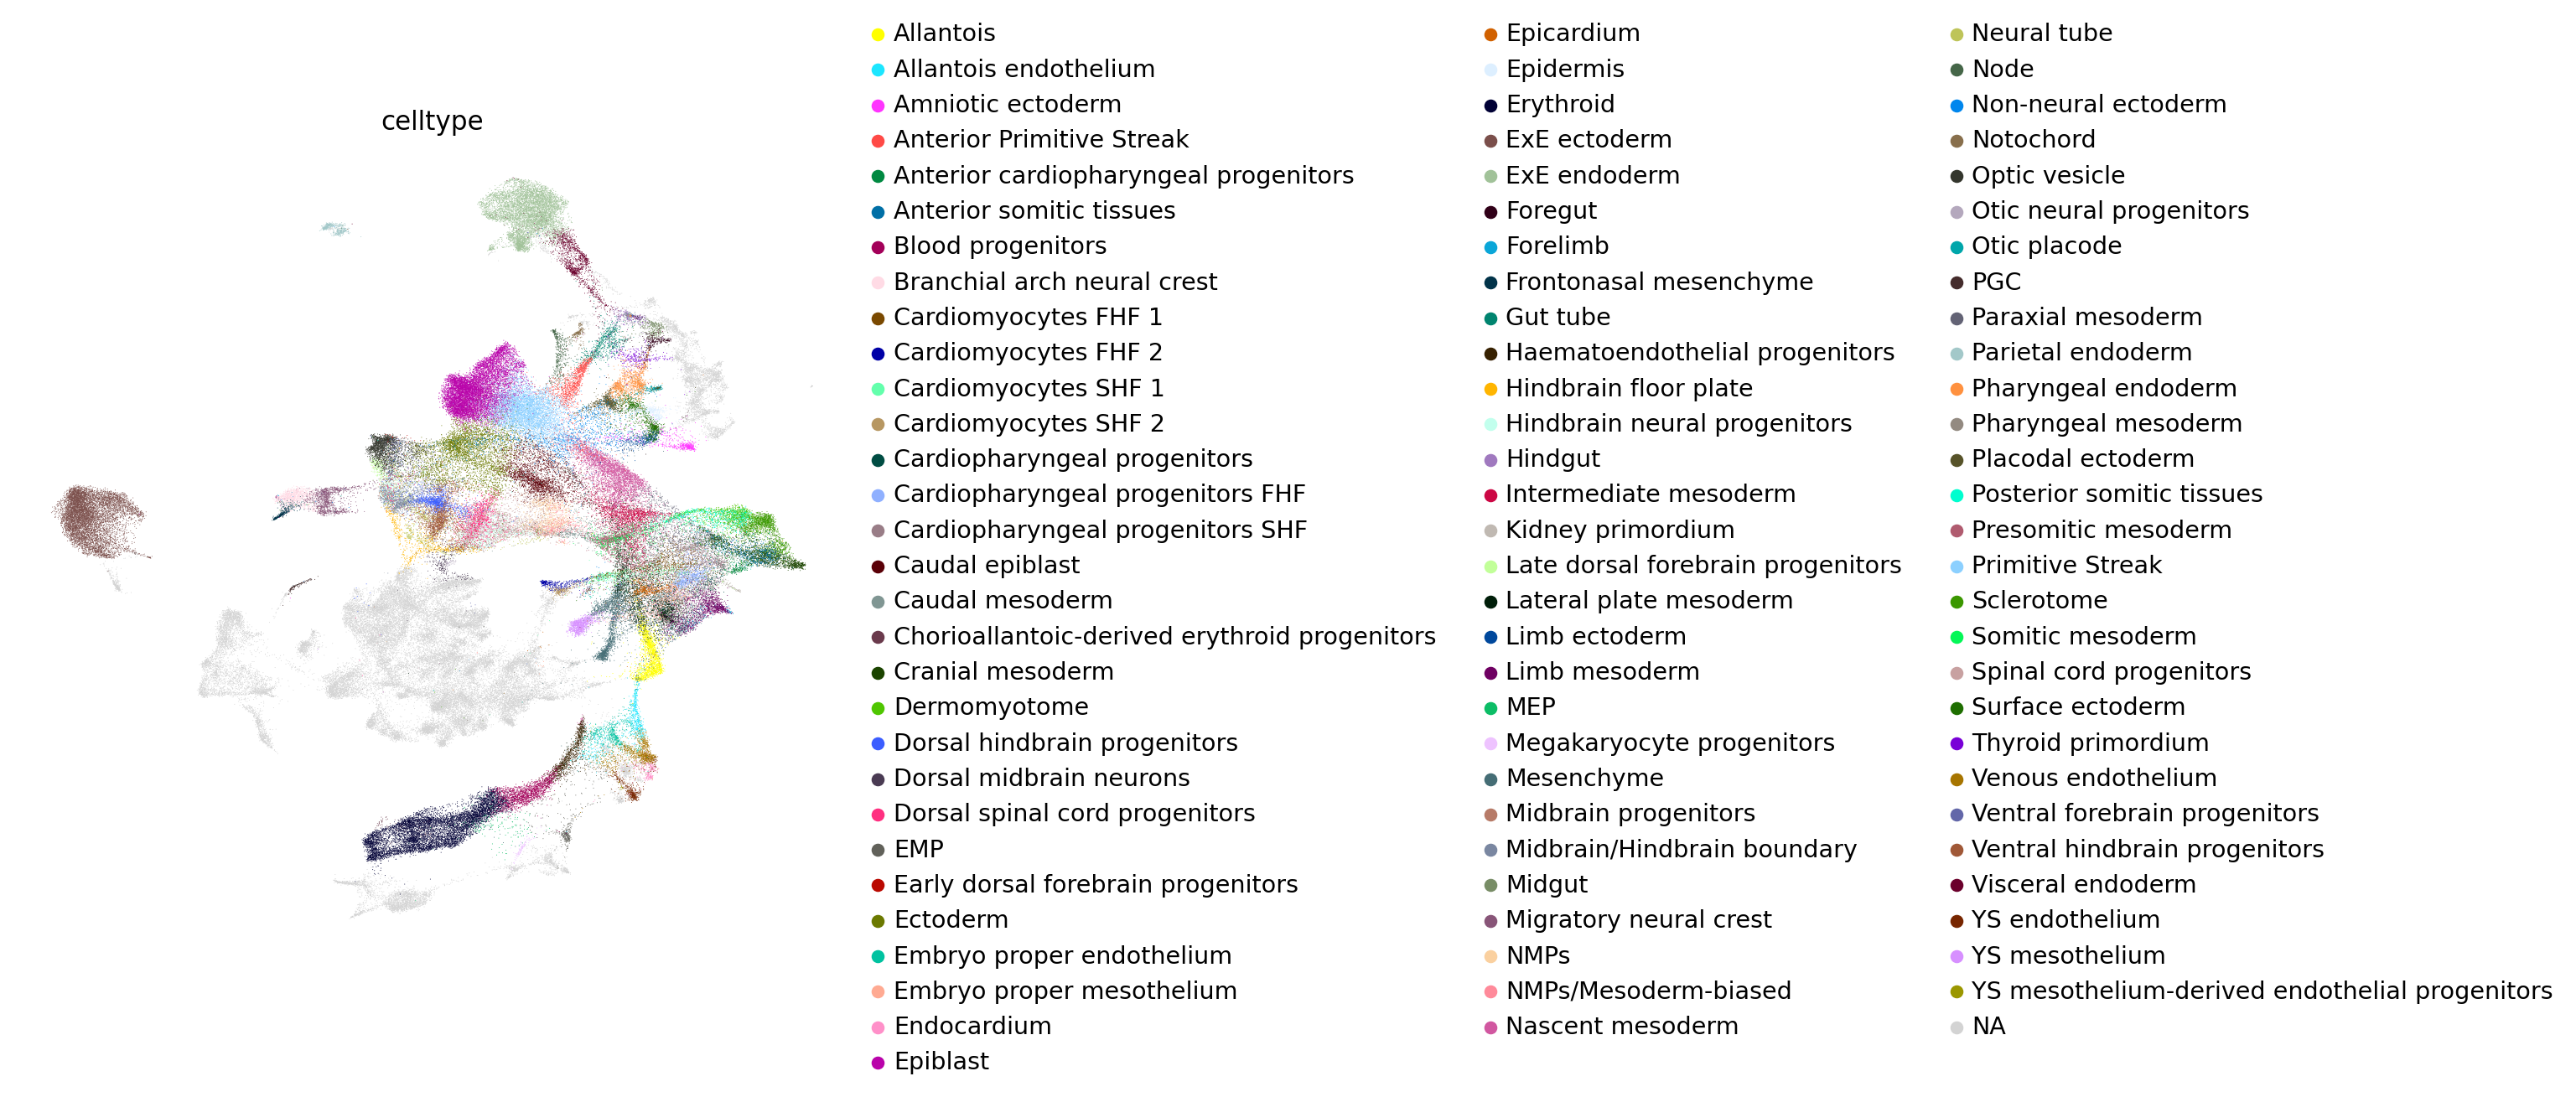

In [44]:
sc.pl.umap(
    adata_full,
    color=["celltype"],
    frameon=False,
    ncols=1 #, legend_loc='none'
)

In [42]:
umap = pd.DataFrame(adata_full.obsm['X_umap'])
latent = pd.DataFrame(adata_full.obsm['X_scVI'])

umap.to_csv('/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/results/rna/scvi/umap_full.csv')
latent.to_csv('/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/results/rna/scvi/latent_full.csv')

# Train scANVI model

In [48]:
scvi.model.SCANVI.setup_anndata(
    adata,
    batch_key="stage",
    categorical_covariate_keys=["sample"],
    labels_key="celltype", #"celltype_original", "stage"],
    layer="counts",
)

INFO     Using batches from adata.obs["stage"]                                               
INFO     Using labels from adata.obs["celltype"]                                             
INFO     Using data from adata.layers["counts"]                                              
INFO     Successfully registered anndata object containing 115559 cells, 2500 vars, 13       
         batches, 87 labels, and 0 proteins. Also registered 1 extra categorical covariates  
         and 0 extra continuous covariates.                                                  
INFO     Please do not further modify adata until model is trained.                          


/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/scvi/data/_anndata.py:315: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  warnings.warn(


In [49]:
scanvi_model = scvi.model.SCANVI.from_scvi_model(model, 'unknown')

In [50]:
scanvi_model

ScanVI Model with the following params: 
unlabeled_category: unknown, n_hidden: 128, n_latent: 40, n_layers: 1, dropout_rate: 0.1, 
dispersion: gene, gene_likelihood: zinb
Training status: Not Trained

To print summary of associated AnnData, use: scvi.data.view_anndata_setup(model.adata)

In [51]:
scanvi_model.train()

INFO     Training for 10 epochs.                                                             


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
Set SLURM handle signals.


Epoch 10/10: 100%|██████████| 10/10 [47:01<00:00, 282.11s/it, loss=1.5e+03, v_num=1]


In [52]:
scanvi_model.save("/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/extended/processed/scanvi_model_2/")

In [53]:
scanvi_model

ScanVI Model with the following params: 
unlabeled_category: unknown, n_hidden: 128, n_latent: 40, n_layers: 1, dropout_rate: 0.1, 
dispersion: gene, gene_likelihood: zinb
Training status: Trained

To print summary of associated AnnData, use: scvi.data.view_anndata_setup(model.adata)

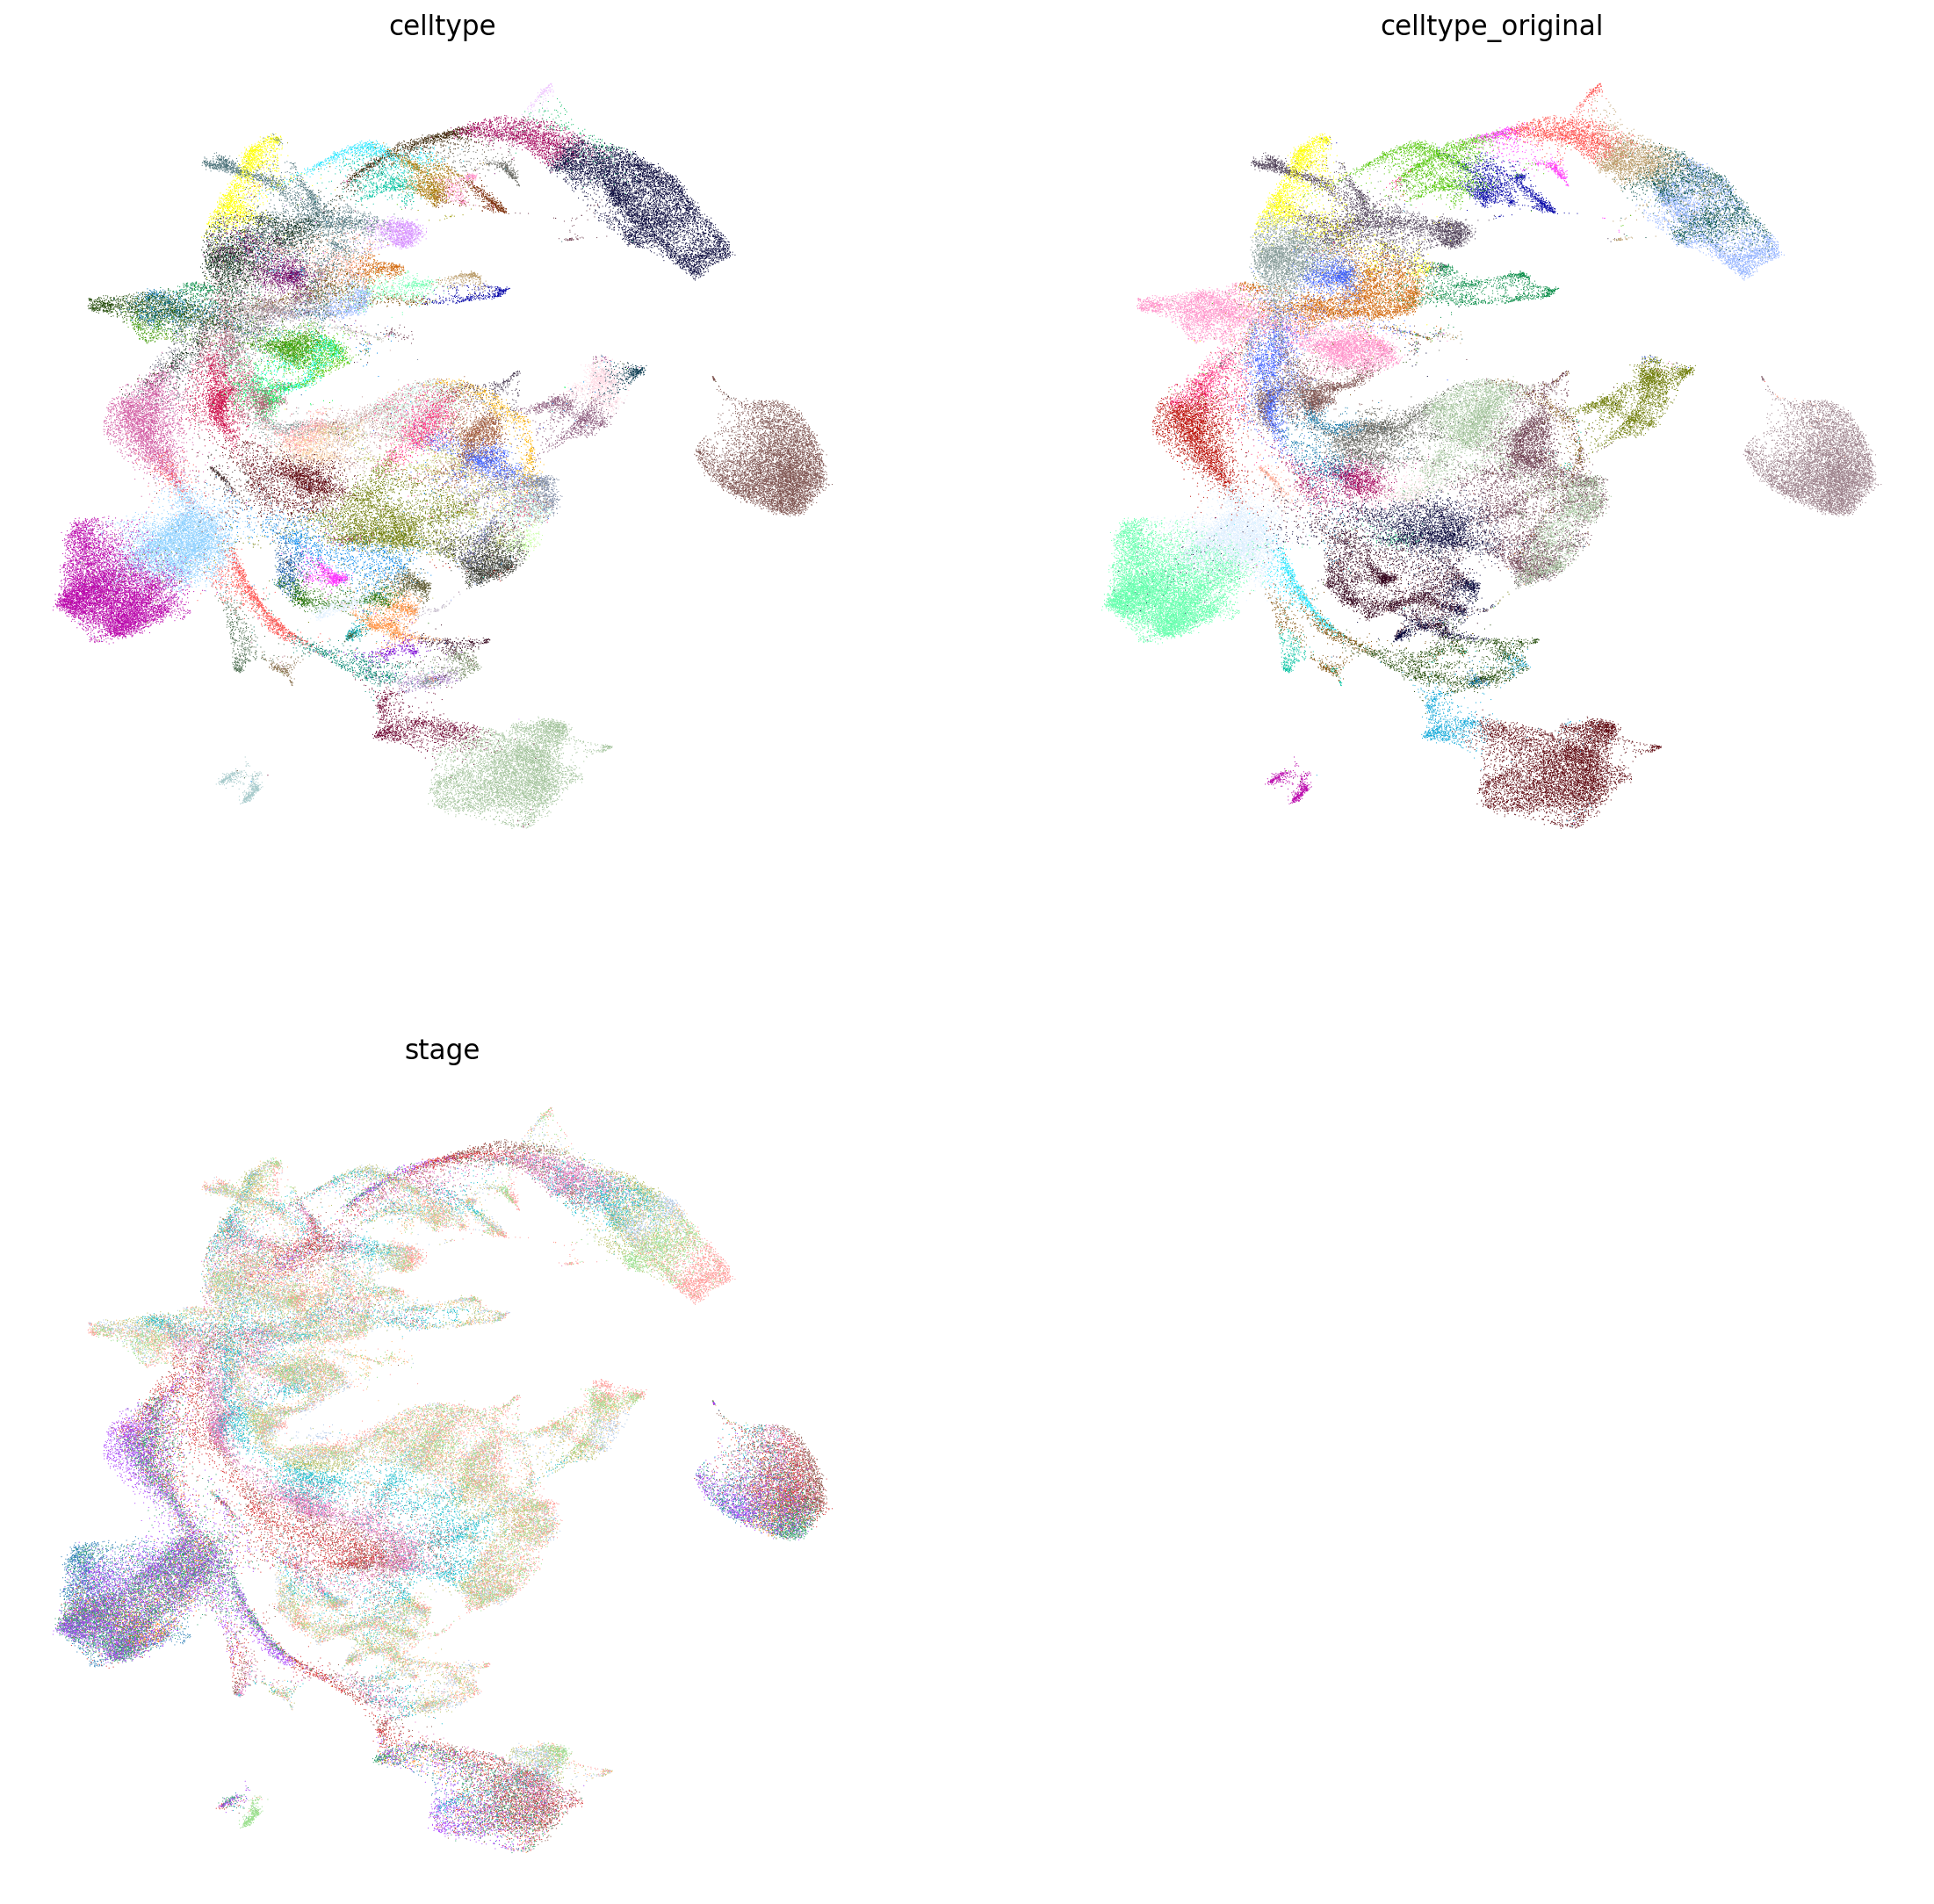

In [54]:
adata.obsm["X_scANVI"] = scanvi_model.get_latent_representation()
sc.pp.neighbors(adata, use_rep="X_scANVI")
sc.tl.leiden(adata)
sc.tl.umap(adata)

sc.pl.umap(
    adata,
    color=["celltype", "celltype_original", "stage"],
    frameon=False,
    ncols=2, legend_loc='none'
)

In [55]:
umap = pd.DataFrame(adata.obsm['X_umap'])
latent = pd.DataFrame(adata.obsm['X_scVI'])

umap.to_csv('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/extended/results/dim_reduction/umap_scanvi.csv')
latent.to_csv('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/extended/results/dim_reduction/latent_scanvi.csv')

# test

In [34]:
scanvi_model

ScanVI Model with the following params: 
unlabeled_category: Unknown, n_hidden: 128, n_latent: 40, n_layers: 1, dropout_rate: 0.1, 
dispersion: gene, gene_likelihood: zinb
Training status: Trained

To print summary of associated AnnData, use: scvi.data.view_anndata_setup(model.adata)

In [56]:
#scanvi_model = scvi.model.SCVI.load("/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/extended/processed/scanvi_model/", adata)

In [57]:
adata_query = sc.read_h5ad("/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/processed/anndata_scanvi.h5ad")

In [58]:
adata_query.layers["counts"] = adata_query.X.copy() # preserve counts
adata_query.raw = adata_query # freeze the state in `.raw`


In [60]:
adata_query.obs["celltype"]  = 'unknown'

In [61]:
vae_q = scvi.model.SCANVI.load_query_data(
    adata_query,
    scanvi_model
)

INFO     Using data from adata.layers["counts"]                                              


/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/scvi/model/base/_archesmixin.py:95: UserWarning: Query integration should be performed using models trained with version >= 0.8
  warnings.warn(
/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function transfer_anndata_setup is deprecated; This method will be removed in 0.15.0. Please avoid building any new dependencies on it.
  warnings.warn(msg, category=FutureWarning)


INFO     Registered keys:['X', 'batch_indices', 'labels', 'cat_covs']                        
INFO     Successfully registered anndata object containing 45670 cells, 2500 vars, 13        
         batches, 88 labels, and 0 proteins. Also registered 1 extra categorical covariates  
         and 0 extra continuous covariates.                                                  


/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/scvi/data/_anndata.py:465: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if c not in mapping:
/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/scvi/data/_anndata.py:315: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  warnings.warn(


In [66]:
vae_q._unlabeled_indices = np.arange(adata_query.n_obs)
vae_q._labeled_indices = []

In [68]:
vae_q.train(
    max_epochs=100,
    plan_kwargs=dict(weight_decay=0.0),
    check_val_every_n_epoch=10,
)

INFO     Training for 100 epochs.                                                            


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
Set SLURM handle signals.


Epoch 100/100: 100%|██████████| 100/100 [1:35:36<00:00, 57.37s/it, loss=2.03e+03, v_num=1]


In [69]:
adata_query.obsm["X_scANVI"] = vae_q.get_latent_representation()
adata_query.obs["predictions"] = vae_q.predict()

In [74]:
sc.pp.neighbors(adata_query, use_rep="X_scANVI", n_neighbors=35)
sc.tl.umap(adata_query, min_dist=0.4)

/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/anndata/_core/anndata.py:1228: FutureWarning: The `inplace` parameter in pandas.Categorical.reorder_categories is deprecated and will be removed in a future version. Reordering categories will always return a new Categorical object.
  c.reorder_categories(natsorted(c.categories), inplace=True)
... storing 'celltype' as categorical
/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/anndata/_core/anndata.py:1228: FutureWarning: The `inplace` parameter in pandas.Categorical.reorder_categories is deprecated and will be removed in a future version. Reordering categories will always return a new Categorical object.
  c.reorder_categories(natsorted(c.categories), inplace=True)
... storing 'predictions' as categorical


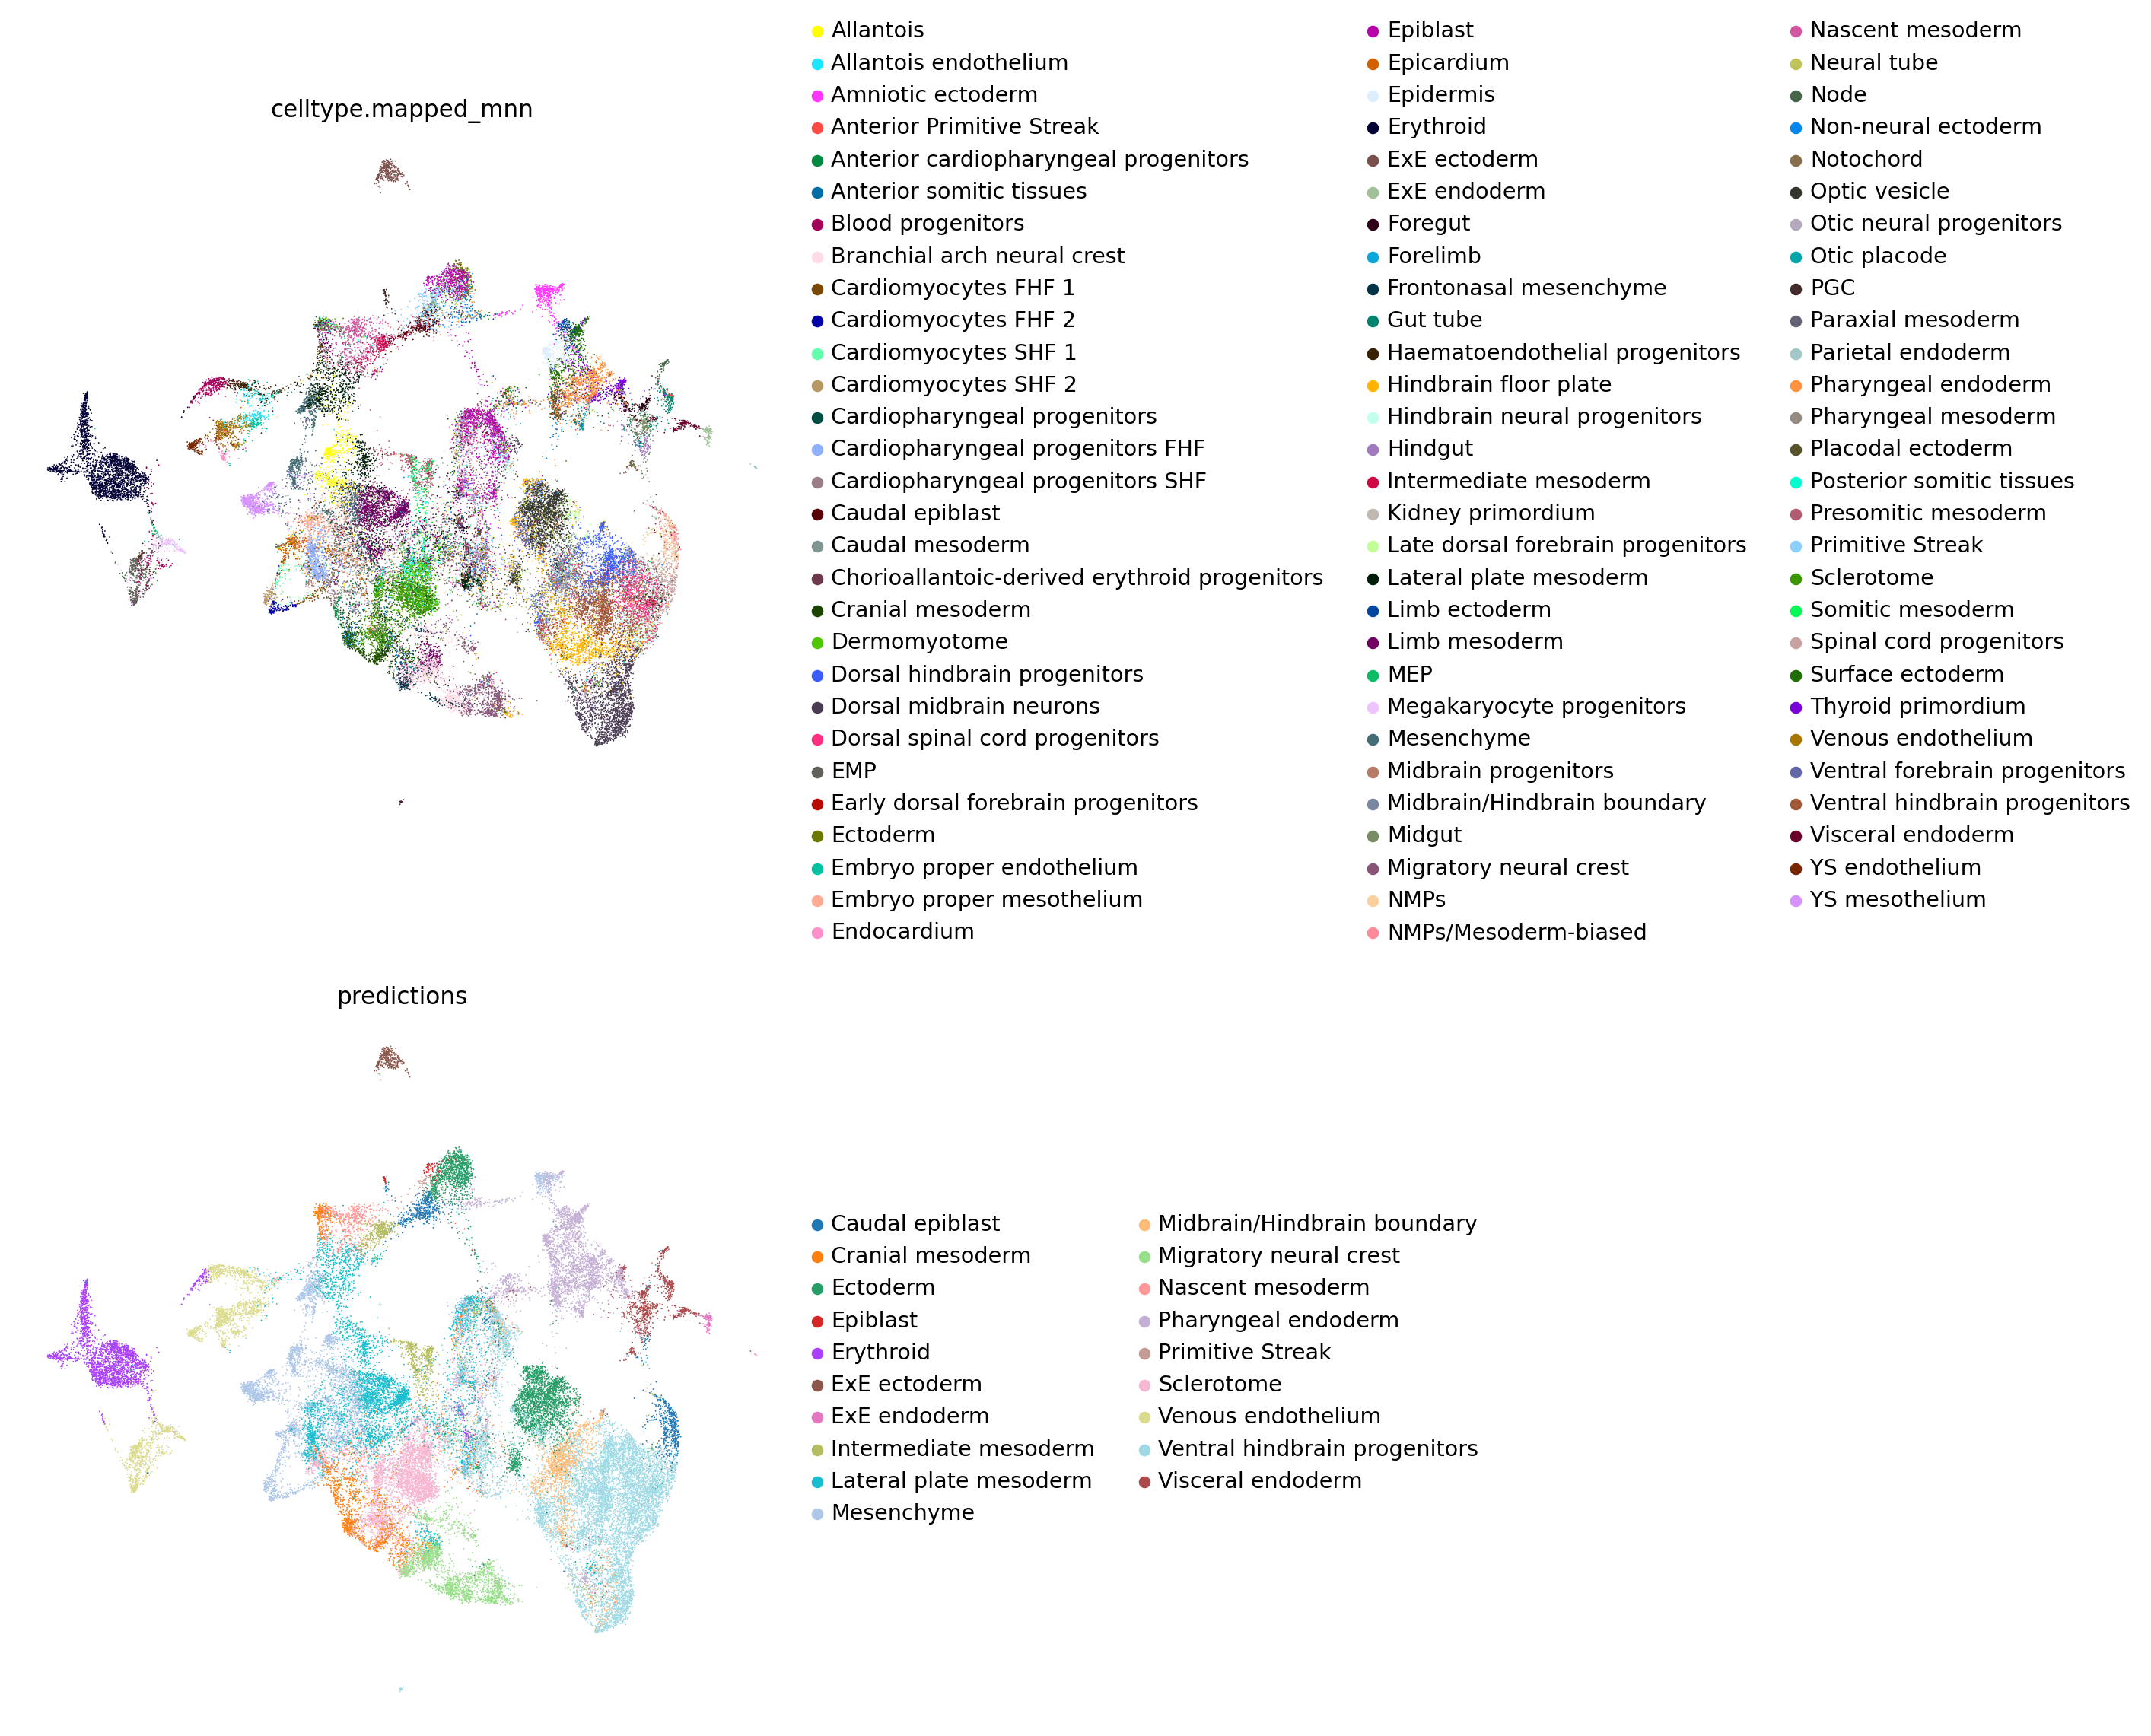

In [75]:
sc.pl.umap(
    adata_query,
    color=["celltype.mapped_mnn", "predictions"],
    frameon=False,
    ncols=1,
)

/tmp/ipykernel_217454/3725619211.py:5: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  _ = plt.pcolor(norm_df)


Text(0, 0.5, 'Observed')

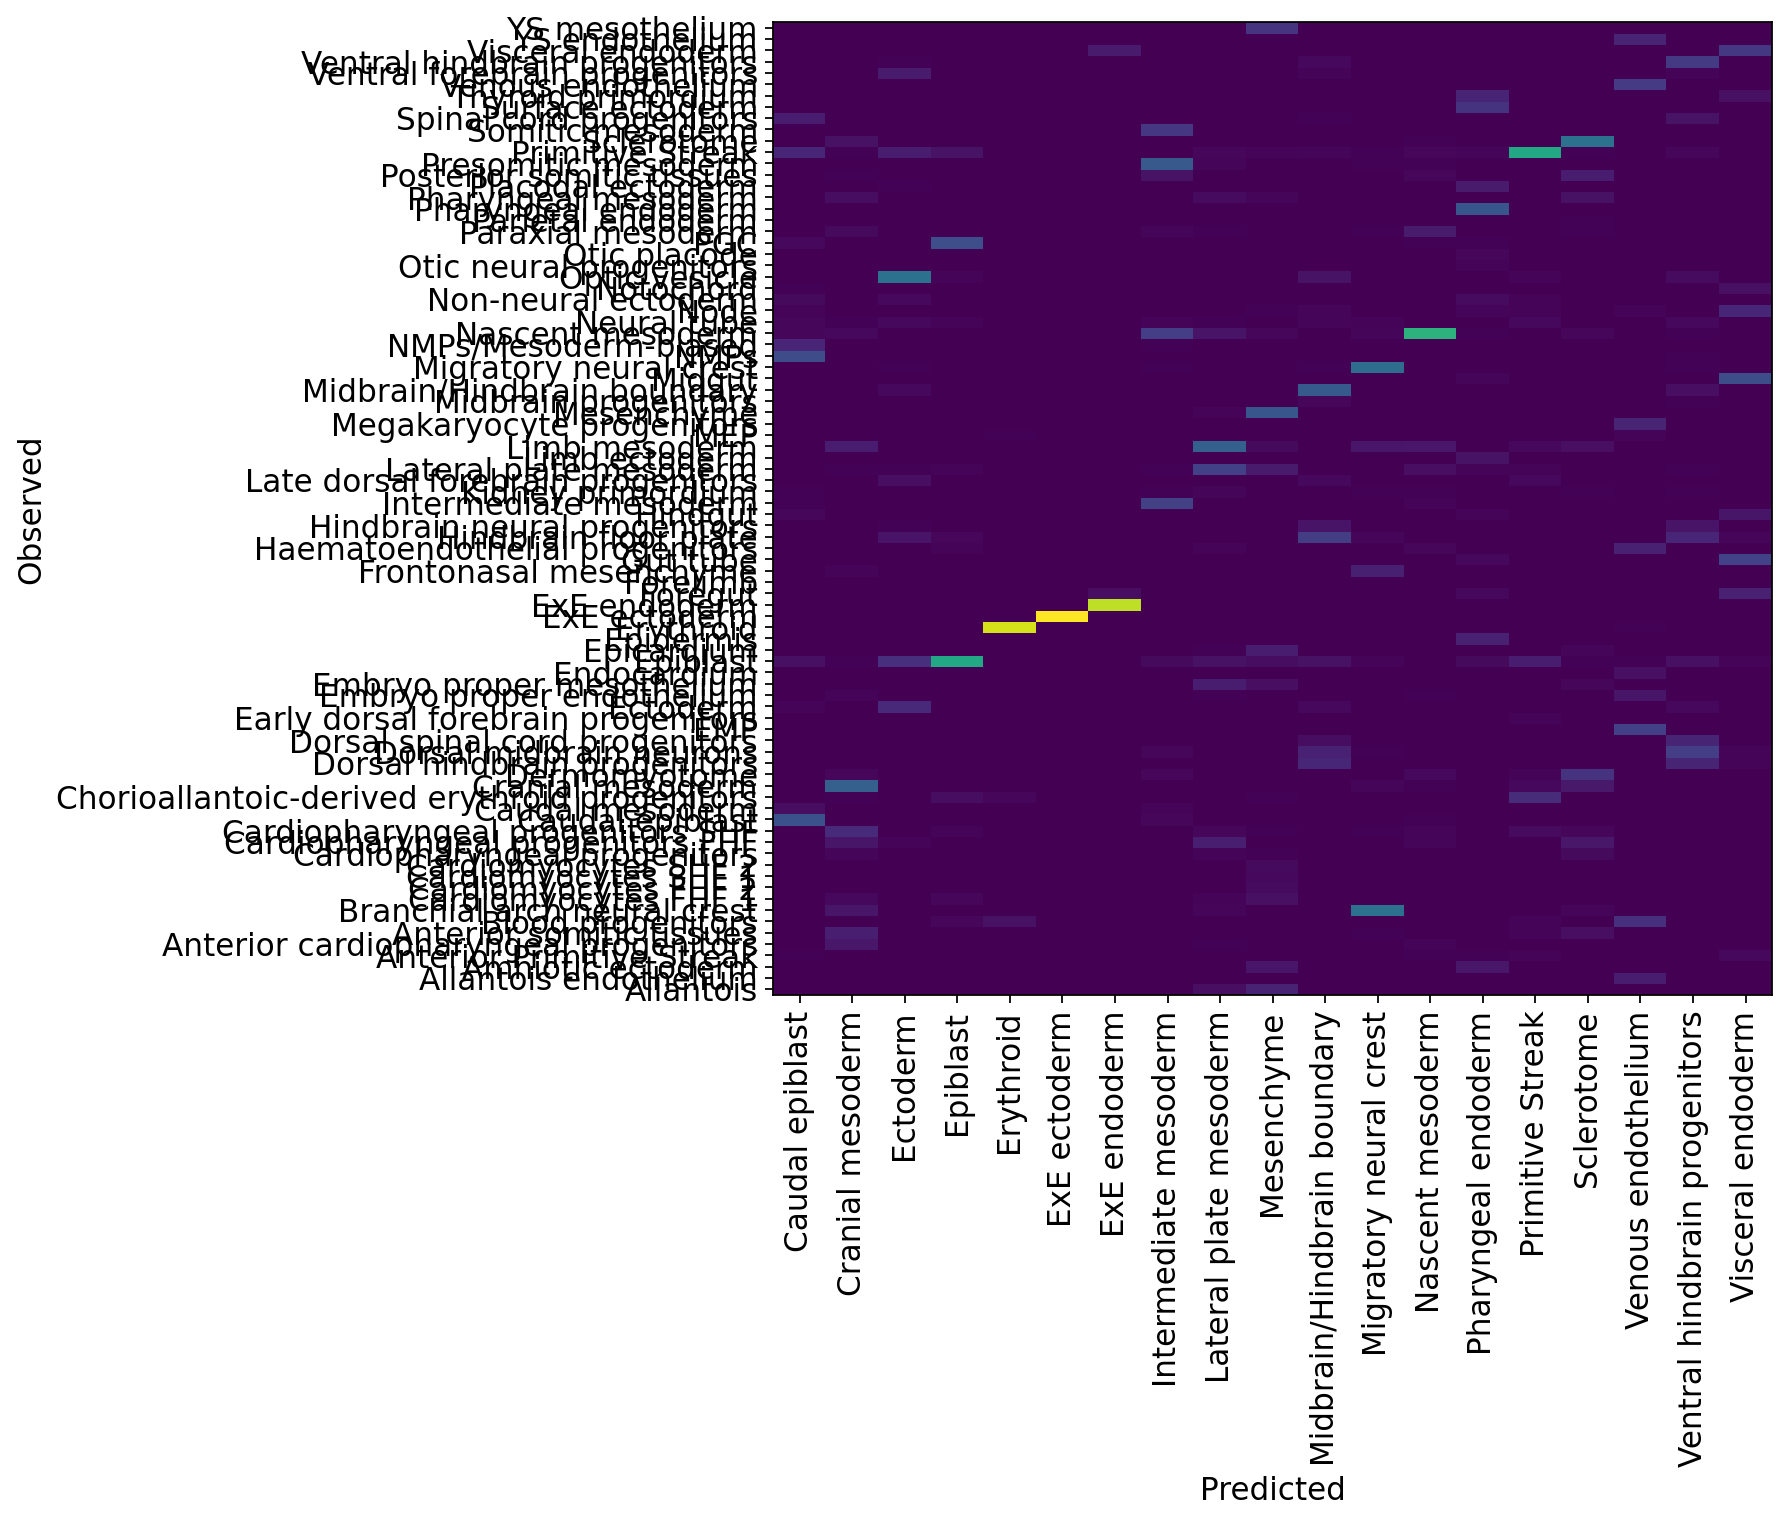

In [73]:
df = adata_query.obs.groupby(["celltype.mapped_mnn", "predictions"]).size().unstack(fill_value=0)
norm_df = df / df.sum(axis=0)

plt.figure(figsize=(8, 8))
_ = plt.pcolor(norm_df)
_ = plt.xticks(np.arange(0.5, len(df.columns), 1), df.columns, rotation=90)
_ = plt.yticks(np.arange(0.5, len(df.index), 1), df.index)
plt.xlabel("Predicted")
plt.ylabel("Observed")

In [121]:
vae_q = scvi.model.SCVI.load_query_data(
    adata_query,
    model,
)

INFO     Using data from adata.layers["counts"]                                              


/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/scvi/model/base/_archesmixin.py:95: UserWarning: Query integration should be performed using models trained with version >= 0.8
  warnings.warn(
/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function transfer_anndata_setup is deprecated; This method will be removed in 0.15.0. Please avoid building any new dependencies on it.
  warnings.warn(msg, category=FutureWarning)


INFO     Registered keys:['X', 'batch_indices', 'labels', 'cat_covs']                        
INFO     Successfully registered anndata object containing 45670 cells, 2500 vars, 13        
         batches, 2 labels, and 0 proteins. Also registered 1 extra categorical covariates   
         and 0 extra continuous covariates.                                                  


/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/scvi/data/_anndata.py:465: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if c not in mapping:
/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/scvi/data/_anndata.py:315: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  warnings.warn(


In [122]:
vae_q.train(max_epochs=200, plan_kwargs=dict(weight_decay=0.0))
adata_query.obsm["X_scVI"] = vae_q.get_latent_representation()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
Set SLURM handle signals.


Epoch 200/200: 100%|██████████| 200/200 [2:02:36<00:00, 36.78s/it, loss=2.06e+03, v_num=1]  


In [123]:
sc.pp.neighbors(adata_query, use_rep="X_scVI")
sc.tl.leiden(adata_query)
sc.tl.umap(adata_query)

In [124]:
sc.pl.umap(
    adata_query,
    color=["tech", "celltype"],
    frameon=False,
    ncols=1,
)

/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/anndata/_core/anndata.py:1228: FutureWarning: The `inplace` parameter in pandas.Categorical.reorder_categories is deprecated and will be removed in a future version. Reordering categories will always return a new Categorical object.
  c.reorder_categories(natsorted(c.categories), inplace=True)
... storing 'celltype' as categorical


KeyError: 'tech'

<Figure size 386.4x640 with 0 Axes>